# Pi-hole dense scan - preregistered calibration

This notebook measures the standalone Pi-hole aggregate grain before the dense-cluster
scan is wired into that path. It is self-contained and bring-your-own-logs: change the
parameter cell, never the measurement functions. The default corpus is the frozen
2026-W28 calibration-estate week. Every displayed result is aggregate-only; no real
row, hostname, domain, or log line is displayed.

The questions and rules below were fixed before running the campaign:

- **E1, HEAD control.** Inject the concentrated shape at N in
  `{15, 50, 100, 200, 400, 1000}` through the real standalone-Pi-hole `runner.run`.
  Record finding counts and the unscanned disclosure. Preserve the lowest observed
  post-cliff arm as U-02's fail-at-HEAD recipe.
- **E2, shared ratio transfer.** Keep unweighted 0.8/0.8 iff every post-cliff
  concentrated arm passes and zero benign frozen-week clusters pass both. Otherwise
  take the minimum-satisfying adjustment, preferring unweighted grain.
- **E3, member floor.** Choose the smallest of `{25, 50, 100}` with zero benign
  surfaced clusters; prefer 25 when the ratios already reject every benign cluster.
- **E4, invariants.** Reconcile member and query-event totals and exactly-once
  accounting. MEDIUM with empty `severity_basis` is the settled U-02 target. Because
  HEAD has no Pi-hole scan seam, this notebook's candidate adapter is explicitly a
  prototype; U-02 owes the real-path assertion.
- **E5, spread scope.** The multi-apex shape should self-cluster and fail the
  registrable-domain share gate.
- **E6, hex parity.** The previously measured seeded hex straddle should behave the
  same at aggregate grain.

Round-2 reviewer controls, added after the first execution and labeled separately
from the preregistration:

- **F2, digit-heavier control.** At N=50, use an exact 24-digit/24-consonant label
  construction and verify that the family clears the shipped unweighted 0.8/0.8
  gates without changing the shared threshold.
- **F3, replacement witness.** Run that same N=50 control through the real HEAD
  runner and preserve it as U-02's fail-at-HEAD regression recipe.

Settled, not experiment arms: ratio keys stay shared across feeds; Pi-hole scan
findings cap at MEDIUM and never receive the volume corroborator.


In [1]:
from __future__ import annotations

from collections import Counter
from contextlib import redirect_stderr, redirect_stdout
from datetime import datetime, timedelta, timezone
from pathlib import Path
import gc
import hashlib
import json
import os
import random
import re
import string
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sigwood import runner
from sigwood.common import loader
from sigwood.detectors import dns


# Parameters. Long execution is opt-in so opening the notebook never launches a
# multi-hour campaign. The recorded calibration output was produced with
# SIGWOOD_CALIBRATE=1 in a clean kernel.
BENIGN_DIR = Path.home() / ".sigwood" / "bench" / "corpus-2026w28" / "pihole"
WORK_ROOT = Path.home() / ".sigwood" / "bench" / "pihole-dense-20260827"
SEED = 20260827
VOLUMES = (15, 50, 100, 200, 400, 1000)
FLOOR_CANDIDATES = (25, 50, 100)
CONTROL_N = 50
RUN_LONG = os.environ.get("SIGWOOD_CALIBRATE") == "1"

# Execution constraints: use local wall-clock text strictly inside W28, and make
# resolved-parent rotation grouping visible before trusting discovery.
INJECTION_START = datetime(2026, 7, 11, 12, 0, 0)  # naive local wall clock
REAL_TLD_SUFFIX = "xyz"  # the sole real-TLD token allowed by the privacy carve-out
DGA_ALPHABET = "0123456789bcdfghjklmnpqrstvwxyz"
DGA_CONSONANTS = "bcdfghjklmnpqrstvwxyz"
SOURCE_CLIENT = "192.0.2.44"
UPSTREAM = "198.51.100.53"

PARAMETERS = {
    "benign_dir": str(BENIGN_DIR),
    "work_root": str(WORK_ROOT),
    "seed": SEED,
    "volumes": VOLUMES,
    "injection_start_local": INJECTION_START.isoformat(),
    "real_tld_suffix": REAL_TLD_SUFFIX,
}
pd.Series(
    {
        "seed": SEED,
        "volumes": VOLUMES,
        "injection_start_local": INJECTION_START.isoformat(),
        "real_tld_suffix": REAL_TLD_SUFFIX,
        "paths": "parameterized under Path.home(); not recorded in output",
    },
    name="value",
)


seed                                                              20260827
volumes                                      (15, 50, 100, 200, 400, 1000)
injection_start_local                                  2026-07-11T12:00:00
real_tld_suffix                                                        xyz
paths                    parameterized under Path.home(); not recorded ...
Name: value, dtype: object

## Isolation, generator, and receipts

Each arm contains links to the frozen seven daily files plus one generated injection
file. The loader groups rotations by **resolved parent plus rotation base**: the links
therefore remain members of the frozen source-parent groups, while the uniquely named
injection stays in its arm parent. We inspect this topology and the discovered count.

The generator emits only seeded, high-entropy random labels. Its source contains a TLD
token but no literal real domain. Materialized names stay bench-side and are never
printed or committed.


In [2]:
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for block in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def write_progress(stage: str, completed: int, total: int, **facts) -> None:
    if not RUN_LONG:
        return
    payload = {
        "stage": stage,
        "completed": completed,
        "total": total,
        "updated_at": datetime.now(timezone.utc).isoformat(),
        **facts,
    }
    (WORK_ROOT / "progress.json").write_text(
        json.dumps(payload, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )


def source_receipt() -> pd.DataFrame:
    paths = sorted(BENIGN_DIR.glob("pihole*.log*"))
    if len(paths) != 7:
        raise RuntimeError(f"expected seven frozen daily files, found {len(paths)}")
    return pd.DataFrame(
        {
            "file": [p.name for p in paths],
            "bytes": [p.stat().st_size for p in paths],
            "mtime_ns": [p.stat().st_mtime_ns for p in paths],
            "sha256": [sha256(p) for p in paths],
        }
    )


def random_label(rng: random.Random, length: int = 48) -> str:
    # Digit presence is structural, not a retry loop with an unrecorded arm.
    body = [rng.choice(DGA_ALPHABET) for _ in range(length - 1)]
    body.insert(rng.randrange(length), rng.choice(string.digits))
    return "".join(body)


def digit_heavy_label(rng: random.Random, length: int = 48) -> str:
    if length % 2:
        raise ValueError("digit-heavy control requires an even label length")
    body = [rng.choice(string.digits) for _ in range(length // 2)]
    body.extend(rng.choice(DGA_CONSONANTS) for _ in range(length // 2))
    rng.shuffle(body)
    return "".join(body)


def arm_names(shape: str, n: int) -> tuple[list[str], str | None]:
    shape_seed = {"concentrated": 0, "spread": 1, "digit_heavy": 2}[shape]
    rng = random.Random((SEED << 16) ^ (n << 2) ^ shape_seed)
    label_fn = digit_heavy_label if shape == "digit_heavy" else random_label
    labels = [label_fn(rng) for _ in range(n)]
    if len(set(labels)) != n:
        raise RuntimeError("seeded labels collided")
    if shape in {"concentrated", "digit_heavy"}:
        parent_label = random_label(random.Random(SEED ^ 0xC0DEC0DE), length=20)
        parent = parent_label + "." + REAL_TLD_SUFFIX
        return [label + "." + parent for label in labels], parent
    if shape == "spread":
        return [label + "." + REAL_TLD_SUFFIX for label in labels], None
    raise ValueError(shape)


def wall_stamp(ts: datetime) -> str:
    return f"{ts.strftime('%b')} {ts.day:2d} {ts:%H:%M:%S}"


def injection_bytes(shape: str, n: int) -> tuple[bytes, set[str], str | None]:
    names, parent = arm_names(shape, n)
    lines: list[str] = []
    for i, domain in enumerate(names):
        ts = INJECTION_START + timedelta(milliseconds=250 * i)
        prefix = f"{wall_stamp(ts)} pihole dnsmasq[1234]: "
        lines.extend(
            (
                prefix + f"query[A] {domain} from {SOURCE_CLIENT}",
                prefix + f"forwarded {domain} to {UPSTREAM}",
                prefix + f"reply {domain} is NXDOMAIN",
            )
        )
    return ("\n".join(lines) + "\n").encode("utf-8"), set(names), parent


def prepare_arm(shape: str, n: int) -> dict[str, object]:
    arm = WORK_ROOT / f"{shape}-n{n}"
    arm.mkdir(parents=True, exist_ok=True)
    source_paths = sorted(BENIGN_DIR.glob("pihole*.log*"))
    for src in source_paths:
        link = arm / src.name
        if not link.exists():
            link.symlink_to(src)
        if link.resolve() != src.resolve():
            raise RuntimeError(f"overlay link drift: {link.name}")

    payload, names, parent = injection_bytes(shape, n)
    injection = arm / "pihole_injection.log"
    if injection.exists():
        if sha256(injection) != hashlib.sha256(payload).hexdigest():
            raise RuntimeError(f"existing injection differs: {shape} N={n}")
    else:
        injection.write_bytes(payload)

    discovered = sorted(arm.glob("pihole*.log*"))
    if len(discovered) != 8:
        raise RuntimeError(f"arm discovery expected 8 files, found {len(discovered)}")
    source_parent_count = len({p.resolve().parent for p in discovered if p.is_symlink()})
    if source_parent_count != 1 or injection.resolve().parent != arm.resolve():
        raise RuntimeError("resolved-parent topology is not the reviewed overlay shape")
    return {
        "shape": shape,
        "n": n,
        "arm": arm,
        "injection": injection,
        "names": names,
        "parent": parent,
        "injection_sha256": sha256(injection),
        "discovered_files": len(discovered),
        "resolved_parent_groups": len({p.resolve().parent for p in discovered}),
    }


RECEIPT_BEFORE = source_receipt()
ARMS: dict[tuple[str, int], dict[str, object]] = {}
if RUN_LONG:
    WORK_ROOT.mkdir(parents=True, exist_ok=True)
    for shape in ("concentrated", "spread"):
        for n in VOLUMES:
            ARMS[(shape, n)] = prepare_arm(shape, n)
    ARMS[("digit_heavy", CONTROL_N)] = prepare_arm("digit_heavy", CONTROL_N)
    write_progress("arms-prepared", len(ARMS), len(VOLUMES) * 2 + 1)

arm_receipt = pd.DataFrame(
    [
        {
            "shape": a["shape"],
            "N": a["n"],
            "files": a["discovered_files"],
            "resolved_parent_groups": a["resolved_parent_groups"],
            "injection_sha256": a["injection_sha256"],
        }
        for a in ARMS.values()
    ]
)
arm_receipt if RUN_LONG else pd.DataFrame({"status": ["set SIGWOOD_CALIBRATE=1 to execute"]})


,shape,N,files,resolved_parent_groups,injection_sha256
0,concentrated,15,8,2,09384ae88c3c22820c201794dc688e4084daa9f21bed76...
1,concentrated,50,8,2,4e148dd969978c8fa4a8fa8041485553cccdac3be9eb26...
2,concentrated,100,8,2,09a2db2d33423f0c332b21932a5d8033068fd116ffdc9d...
3,concentrated,200,8,2,03cda9dd06719241cea3e5282425748c5fd601b7b18c5a...
4,concentrated,400,8,2,4525880508c93195971392d98cabf0ba880764d8f6db0f...
5,concentrated,1000,8,2,7615160d61ca4941c8d009aacbf125f2c7fbc63c41540a...
6,spread,15,8,2,5a39f8b1dde8b6a99898d3a7df3d4e02b9b135ad85bd2c...
7,spread,50,8,2,fa5000ff070d463d439fb4610dae4c2045c026d5b4976f...
8,spread,100,8,2,f16065e3a3ada887fa59e198c15a0e5efa7e8a220ec58b...
9,spread,200,8,2,d76bce103e229fc72e6df6cf403f39d2b473d4c8208ce2...


## E1 - real HEAD control

Every concentrated arm is run through `runner.run` in standalone Pi-hole mode with
the shipped DNS defaults. `load_all=True` selects the full frozen week; it does not
retune the detector. JSON and diagnostics remain bench-side. The table exposes only
counts and the disclosure tier.


In [3]:
def nested_strings(value):
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from nested_strings(item)
    elif isinstance(value, (list, tuple)):
        for item in value:
            yield from nested_strings(item)


def finding_hits_arm(finding: dict, names: set[str], parent: str | None) -> bool:
    values = set(nested_strings(finding))
    if parent is not None and parent in values:
        return True
    return bool(values.intersection(names))


def run_head_arm(arm_info: dict[str, object]) -> dict[str, object]:
    arm = arm_info["arm"]
    report = arm / "head-control.json"
    diagnostics = arm / "head-control.log"
    cfg = {"sigwood": {"detect": "dns", "default_window": "7d", "warn_above": 0}}
    started = time.monotonic()
    with diagnostics.open("w", encoding="utf-8") as log, redirect_stdout(log), redirect_stderr(log):
        rc = runner.run(
            cfg,
            detect="dns",
            pihole_dir=arm,
            output_format="json",
            output_file=report,
            load_all=True,
            skip_confirm=True,
            quiet=True,
            scope=frozenset({"pihole_dir"}),
            invocation="calibration notebook E1",
        )
    if rc != 0:
        raise RuntimeError(f"real runner failed for {arm_info['shape']} N={arm_info['n']}")
    payload = json.loads(report.read_text(encoding="utf-8"))
    findings = [f for f in payload.get("findings", []) if f.get("detector") == "dns"]
    run_summary = payload.get("run_summary") or {}
    record_counts = run_summary.get("record_counts") or {}
    unscanned = [f for f in findings if f.get("evidence", {}).get("tier") == "unscanned_clusters"]
    arm_hits = [
        f for f in findings
        if finding_hits_arm(f, arm_info["names"], arm_info["parent"])
        and f.get("evidence", {}).get("tier") != "unscanned_clusters"
    ]
    evidence = unscanned[0].get("evidence", {}) if unscanned else {}
    return {
        "N": arm_info["n"],
        "loaded_rows": int(record_counts.get("pihole*.log*", 0)),
        "dns_findings": len(findings),
        "injected_findings": len(arm_hits),
        "unscanned_rows": len(unscanned),
        "unscanned_clusters": evidence.get("cluster_count", 0),
        "unscanned_members": evidence.get("total_members", 0),
        "seconds": round(time.monotonic() - started, 2),
        "return_code": rc,
    }


E1_ROWS: list[dict[str, object]] = []
F3_HEAD_ROWS: list[dict[str, object]] = []
if RUN_LONG:
    for index, n in enumerate(VOLUMES, start=1):
        E1_ROWS.append(run_head_arm(ARMS[("concentrated", n)]))
        write_progress("E1-real-runner", index, len(VOLUMES), N=n)
    F3_HEAD_ROWS.append(run_head_arm(ARMS[("digit_heavy", CONTROL_N)]))
    write_progress("F3-real-runner", 1, 1, N=CONTROL_N)
E1 = pd.DataFrame(E1_ROWS)
F3_HEAD = pd.DataFrame(F3_HEAD_ROWS)
E1


,N,loaded_rows,dns_findings,injected_findings,unscanned_rows,unscanned_clusters,unscanned_members,seconds,return_code
0,15,3823798,12,1,1,8,753,32.05,0
1,50,3823903,11,0,1,9,814,32.40,0
2,100,3824053,11,0,1,10,878,32.28,0
3,200,3824353,11,0,1,11,1008,32.42,0
4,400,3824953,11,0,1,12,1253,32.27,0
5,1000,3826753,9,0,1,11,1875,32.79,0


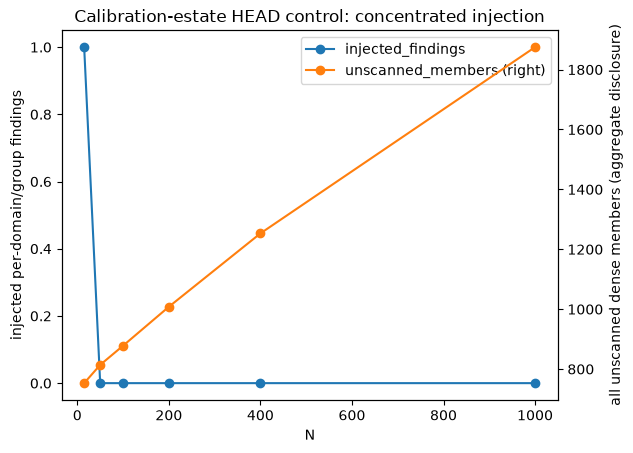

In [4]:
if RUN_LONG:
    ax = E1.plot(
        x="N",
        y=["injected_findings", "unscanned_members"],
        marker="o",
        secondary_y="unscanned_members",
        title="Calibration-estate HEAD control: concentrated injection",
    )
    ax.set_ylabel("injected per-domain/group findings")
    ax.right_ax.set_ylabel("all unscanned dense members (aggregate disclosure)")
    plt.show()


## E2 and E3 - aggregate-grain gate transfer and benign census

The frozen week is loaded once through the product loader. Each arm's injection is
also parsed by that loader, then composed in memory for clustering. Cluster tables
retain counts and ratios only; names never enter notebook output.


In [5]:
def cluster_frame(raw: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    aggregate = dns._build_pihole_aggregate(raw)
    features = dns._build_pihole_features(aggregate)
    cfg = dns.DEFAULT_CONFIG["pihole"]
    labels = dns.fit_predict_interruptible(
        np.ascontiguousarray(features.to_numpy(dtype=np.float64)),
        min_cluster_size=cfg["min_cluster_size"],
        min_samples=cfg["min_samples"],
    )
    return aggregate, labels


def cluster_census(
    aggregate: pd.DataFrame,
    labels: np.ndarray,
    injected: set[str] | None = None,
) -> pd.DataFrame:
    injected = injected or set()
    rows: list[dict[str, object]] = []
    for label in sorted(set(labels) - {-1}):
        member = aggregate.loc[labels == label].copy()
        ext = member["query"].apply(dns._TLD_EXTRACT)
        score = pd.Series(
            [dns._max_subdomain_entropy(q, e) for q, e in zip(member["query"], ext)],
            index=member.index,
        )
        reg = pd.Series(
            [dns._registrable_key(q, e) for q, e in zip(member["query"], ext)],
            index=member.index,
        )
        weight = member["query_count"].astype(float)
        reg_counts = reg.value_counts()
        dominant = str(reg_counts.index[0])
        dominant_mask = reg == dominant
        injected_mask = member["query"].isin(injected)
        rows.append(
            {
                "cluster": int(label),
                "members": int(len(member)),
                "query_events": int(weight.sum()),
                "frac_hi": float((score >= 1.8).mean()),
                "share": float(dominant_mask.mean()),
                "weighted_frac_hi": float(np.average(score >= 1.8, weights=weight)),
                "weighted_share": float(weight[dominant_mask].sum() / weight.sum()),
                "injected_members": int(injected_mask.sum()),
                "injected_fraction": float(injected_mask.mean()),
                "dominant_injected": bool(dominant in injected),
            }
        )
    return pd.DataFrame(rows)


BENIGN_RAW = None
BENIGN_AGG = None
BENIGN_LABELS = None
BENIGN_CENSUS = pd.DataFrame()
CONCENTRATED_CENSUS: dict[int, pd.DataFrame] = {}
DIGIT_HEAVY_CENSUS = pd.DataFrame()
if RUN_LONG:
    BENIGN_RAW = loader.load_pihole(BENIGN_DIR, show_progress=False)
    BENIGN_AGG, BENIGN_LABELS = cluster_frame(BENIGN_RAW)
    BENIGN_CENSUS = cluster_census(BENIGN_AGG, BENIGN_LABELS)
    for index, n in enumerate(VOLUMES, start=1):
        arm = ARMS[("concentrated", n)]
        injected_raw = loader.load_pihole(
            arm["arm"], _files=[arm["injection"]], show_progress=False
        )
        combined = pd.concat([BENIGN_RAW, injected_raw], ignore_index=True)
        aggregate, labels = cluster_frame(combined)
        CONCENTRATED_CENSUS[n] = cluster_census(aggregate, labels, arm["names"])
        del injected_raw, combined, aggregate, labels
        gc.collect()
        write_progress("E2-E3-concentrated", index, len(VOLUMES), N=n)
    control = ARMS[("digit_heavy", CONTROL_N)]
    control_raw = loader.load_pihole(
        control["arm"], _files=[control["injection"]], show_progress=False
    )
    control_combined = pd.concat([BENIGN_RAW, control_raw], ignore_index=True)
    control_aggregate, control_labels = cluster_frame(control_combined)
    DIGIT_HEAVY_CENSUS = cluster_census(
        control_aggregate, control_labels, control["names"]
    )
    del control_raw, control_combined, control_aggregate, control_labels
    gc.collect()
    write_progress("F2-digit-heavy-control", 1, 1, N=CONTROL_N)

benign_summary = pd.DataFrame(
    {
        "loaded_events": [len(BENIGN_RAW) if BENIGN_RAW is not None else 0],
        "aggregate_domains": [len(BENIGN_AGG) if BENIGN_AGG is not None else 0],
        "clusters": [len(BENIGN_CENSUS)],
        "members_min": [int(BENIGN_CENSUS["members"].min()) if len(BENIGN_CENSUS) else 0],
        "members_median": [float(BENIGN_CENSUS["members"].median()) if len(BENIGN_CENSUS) else 0],
        "members_max": [int(BENIGN_CENSUS["members"].max()) if len(BENIGN_CENSUS) else 0],
        "pass_0.8_0.8": [
            int(((BENIGN_CENSUS["frac_hi"] >= 0.8) & (BENIGN_CENSUS["share"] >= 0.8)).sum())
            if len(BENIGN_CENSUS) else 0
        ],
    }
)
benign_summary


,loaded_events,aggregate_domains,clusters,members_min,members_median,members_max,pass_0.8_0.8
0,3823753,2947,21,25,40.0,572,0


In [6]:
def injected_cluster_row(census: pd.DataFrame) -> pd.Series | None:
    if census.empty or census["injected_members"].max() == 0:
        return None
    return census.sort_values(
        ["injected_members", "injected_fraction"], ascending=False
    ).iloc[0]


arm_gate_rows: list[dict[str, object]] = []
if RUN_LONG:
    for n, census in CONCENTRATED_CENSUS.items():
        target = injected_cluster_row(census)
        arm_gate_rows.append(
            {
                "N": n,
                "self_clustered": bool(target is not None and target["injected_members"] == n),
                "injected_cluster_members": int(target["injected_members"]) if target is not None else 0,
                "cluster_members": int(target["members"]) if target is not None else 0,
                "frac_hi": float(target["frac_hi"]) if target is not None else np.nan,
                "share": float(target["share"]) if target is not None else np.nan,
                "weighted_frac_hi": float(target["weighted_frac_hi"]) if target is not None else np.nan,
                "weighted_share": float(target["weighted_share"]) if target is not None else np.nan,
                "passes_0.8_0.8": bool(
                    target is not None and target["frac_hi"] >= 0.8 and target["share"] >= 0.8
                ),
            }
        )
CONCENTRATED_GATES = pd.DataFrame(arm_gate_rows)

digit_heavy_target = injected_cluster_row(DIGIT_HEAVY_CENSUS)
DIGIT_HEAVY_GATE = pd.DataFrame(
    [{
        "N": CONTROL_N,
        "digit_share": 0.5,
        "self_clustered": bool(
            digit_heavy_target is not None
            and digit_heavy_target["injected_members"] == CONTROL_N
        ),
        "injected_cluster_members": (
            int(digit_heavy_target["injected_members"])
            if digit_heavy_target is not None else 0
        ),
        "cluster_members": (
            int(digit_heavy_target["members"])
            if digit_heavy_target is not None else 0
        ),
        "frac_hi": (
            float(digit_heavy_target["frac_hi"])
            if digit_heavy_target is not None else np.nan
        ),
        "share": (
            float(digit_heavy_target["share"])
            if digit_heavy_target is not None else np.nan
        ),
        "passes_0.8_0.8": bool(
            digit_heavy_target is not None
            and digit_heavy_target["frac_hi"] >= 0.8
            and digit_heavy_target["share"] >= 0.8
        ),
    }]
)

post_cliff = (
    CONCENTRATED_GATES[CONCENTRATED_GATES["self_clustered"]]
    if RUN_LONG else pd.DataFrame()
)


def minimum_satisfying_ratios() -> tuple[str, float, float, int] | None:
    '''Apply E2: closest pair to 0.8/0.8; unweighted grain wins ties.

    A gate can sit at the default, the weakest injected arm, or just above an
    observed benign value. Those are the only boundaries where pass/fail changes.
    '''
    if not RUN_LONG or post_cliff.empty:
        return None
    candidates: list[tuple[float, int, float, float, str]] = []
    for grain_rank, (grain, frac_col, share_col) in enumerate(
        (
            ("unweighted", "frac_hi", "share"),
            ("query_count_weighted", "weighted_frac_hi", "weighted_share"),
        )
    ):
        min_injected_frac = float(post_cliff[frac_col].min())
        min_injected_share = float(post_cliff[share_col].min())
        frac_values = {0.8, min_injected_frac}
        share_values = {0.8, min_injected_share}
        frac_values.update(float(np.nextafter(v, 1.0)) for v in BENIGN_CENSUS[frac_col])
        share_values.update(float(np.nextafter(v, 1.0)) for v in BENIGN_CENSUS[share_col])
        for frac_floor in frac_values:
            if not 0 <= frac_floor <= min_injected_frac:
                continue
            for share_floor in share_values:
                if not 0 <= share_floor <= min_injected_share:
                    continue
                benign_pass = int(
                    (
                        (BENIGN_CENSUS[frac_col] >= frac_floor)
                        & (BENIGN_CENSUS[share_col] >= share_floor)
                    ).sum()
                )
                if benign_pass:
                    continue
                distance = abs(frac_floor - 0.8) + abs(share_floor - 0.8)
                candidates.append(
                    (distance, grain_rank, frac_floor, share_floor, grain)
                )
    if not candidates:
        return None
    _distance, _rank, frac_floor, share_floor, grain = min(
        candidates,
        key=lambda item: (
            item[0], item[1], abs(item[2] - 0.8), abs(item[3] - 0.8),
            -item[2], -item[3],
        ),
    )
    return grain, frac_floor, share_floor, 0


ORIGINAL_RATIO_SENSITIVITY = minimum_satisfying_ratios()
RATIO_GRAIN = "unweighted"
SELECTED_FRAC = 0.8
SELECTED_SHARE = 0.8
SELECTED_BENIGN_PASS = int(
    (
        (BENIGN_CENSUS["frac_hi"] >= SELECTED_FRAC)
        & (BENIGN_CENSUS["share"] >= SELECTED_SHARE)
    ).sum()
) if RUN_LONG else -1
KEEP_SHARED_RATIOS = bool(
    RUN_LONG
    and bool(DIGIT_HEAVY_GATE["passes_0.8_0.8"].iloc[0])
    and SELECTED_BENIGN_PASS == 0
    and RATIO_GRAIN == "unweighted"
    and np.isclose(SELECTED_FRAC, 0.8)
    and np.isclose(SELECTED_SHARE, 0.8)
)
selected_frac_col = "weighted_frac_hi" if RATIO_GRAIN == "query_count_weighted" else "frac_hi"
selected_share_col = "weighted_share" if RATIO_GRAIN == "query_count_weighted" else "share"

floor_rows: list[dict[str, object]] = []
if RUN_LONG:
    for floor in FLOOR_CANDIDATES:
        surfaced = BENIGN_CENSUS[
            (BENIGN_CENSUS["members"] >= floor)
            & (BENIGN_CENSUS[selected_frac_col] >= SELECTED_FRAC)
            & (BENIGN_CENSUS[selected_share_col] >= SELECTED_SHARE)
        ]
        floor_rows.append({"floor": floor, "benign_clusters_surfaced": len(surfaced)})
FLOOR_TABLE = pd.DataFrame(floor_rows)
CHOSEN_FLOOR = (
    int(FLOOR_TABLE.loc[FLOOR_TABLE["benign_clusters_surfaced"] == 0, "floor"].min())
    if RUN_LONG and (FLOOR_TABLE["benign_clusters_surfaced"] == 0).any()
    else None
)

CONCENTRATED_GATES, FLOOR_TABLE, pd.DataFrame(
    [{
        "ratio_grain": RATIO_GRAIN,
        "selected_high_score_fraction": SELECTED_FRAC,
        "selected_regdomain_share": SELECTED_SHARE,
        "benign_ratio_passes": SELECTED_BENIGN_PASS,
        "keep_unweighted_0.8_0.8": KEEP_SHARED_RATIOS,
        "round1_original_shape_boundary": (
            ORIGINAL_RATIO_SENSITIVITY[1]
            if ORIGINAL_RATIO_SENSITIVITY is not None else np.nan
        ),
        "chosen_floor": CHOSEN_FLOOR,
    }]
)


(      N  self_clustered  injected_cluster_members  cluster_members   frac_hi  \
 0    15           False                         0                0       NaN   
 1    50            True                        50               51  0.823529   
 2   100            True                       100              100  0.790000   
 3   200            True                       200              200  0.745000   
 4   400            True                       400              400  0.807500   
 5  1000            True                      1000             1000  0.792000   
 
       share  weighted_frac_hi  weighted_share  passes_0.8_0.8  
 0       NaN               NaN             NaN           False  
 1  0.980392          0.823529        0.980392            True  
 2  1.000000          0.790000        1.000000           False  
 3  1.000000          0.745000        1.000000           False  
 4  1.000000          0.807500        1.000000            True  
 5  1.000000          0.792000        1.0

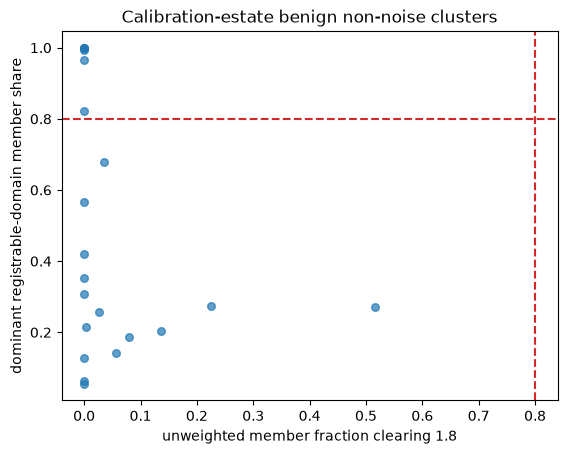

In [7]:
if RUN_LONG and len(BENIGN_CENSUS):
    ax = BENIGN_CENSUS.plot.scatter(
        x="frac_hi", y="share", s=30, alpha=0.7,
        title="Calibration-estate benign non-noise clusters",
    )
    ax.axvline(0.8, color="tab:red", linestyle="--")
    ax.axhline(0.8, color="tab:red", linestyle="--")
    ax.set_xlabel("unweighted member fraction clearing 1.8")
    ax.set_ylabel("dominant registrable-domain member share")
    plt.show()


## F2 and F3 - reviewer-requested control and replacement witness

These are round-2 controls, not retroactive preregistration. F2 holds N=50 and the
parent shape fixed while replacing the original alphabet draw with labels containing
exactly 24 digits and 24 no-vowel consonants in seeded shuffled order. F3 runs the
same arm through the real HEAD runner. The shared 0.8/0.8 values stay fixed.


In [8]:
DIGIT_HEAVY_GATE, F3_HEAD


(    N  digit_share  self_clustered  injected_cluster_members  cluster_members  \
 0  50          0.5            True                        50               51   
 
     frac_hi     share  passes_0.8_0.8  
 0  0.980392  0.980392            True  ,
     N  loaded_rows  dns_findings  injected_findings  unscanned_rows  \
 0  50      3823903            11                  0               1   
 
    unscanned_clusters  unscanned_members  seconds  return_code  
 0                   9                814    32.27            0  )

## E4 - prototype accounting and settled severity target

HEAD cannot run a Pi-hole dense scan, so the adapter below is a deliberately narrow
measurement seam, not product behavior. It surfaces the observed target cluster's
dominant-parent aggregate rows, weighs only true query totals, and sends them through
the current shared back half. Any current HIGH result is a pre-implementation witness:
U-02 must make Pi-hole dense-origin volume non-corroborating and pin MEDIUM with an
empty basis through the real runner.


In [9]:
def prototype_candidates(
    aggregate: pd.DataFrame,
    labels: np.ndarray,
    injected: set[str],
    member_floor: int,
) -> tuple[pd.DataFrame, dict[str, int]]:
    census = cluster_census(aggregate, labels, injected)
    target = injected_cluster_row(census)
    if target is None:
        return pd.DataFrame(), {"injected": len(injected), "dense": 0, "noise": len(injected)}
    label = int(target["cluster"])
    member = aggregate.loc[labels == label].copy()
    ext = member["query"].apply(dns._TLD_EXTRACT)
    member["label_entropy"] = [
        dns._max_subdomain_entropy(q, e) for q, e in zip(member["query"], ext)
    ]
    member["registrable_domain"] = [
        dns._registrable_key(q, e) for q, e in zip(member["query"], ext)
    ]
    member["has_public_suffix"] = [dns._has_public_suffix(e) for e in ext]
    dominant = member["registrable_domain"].value_counts().index[0]
    dense = member[member["registrable_domain"] == dominant].copy()
    if len(member) < member_floor:
        dense = dense.iloc[0:0]
    dense["dense_cluster_id"] = label
    dense["cluster_true_member_count"] = len(dense)
    dense["cluster_true_query_total"] = int(dense["query_count"].sum())
    dense["source"] = "pihole"
    injected_dense = set(dense.loc[dense["query"].isin(injected), "query"])
    injected_noise = injected - injected_dense
    if injected_dense & injected_noise:
        raise AssertionError("injected member counted in dense and noise")
    accounting = {
        "injected": len(injected),
        "dense": len(injected_dense),
        "noise": len(injected_noise),
        "candidate_members": len(dense),
        "candidate_query_events": int(dense["query_count"].sum()),
        "recorded_query_events": int(dense["cluster_true_query_total"].iloc[0]) if len(dense) else 0,
    }
    return dense, accounting


E4_ROWS: list[dict[str, object]] = []
if RUN_LONG:
    control_values = [CONTROL_N]
    for index, n in enumerate(control_values, start=1):
        arm = ARMS[("digit_heavy", int(n))]
        injected_raw = loader.load_pihole(
            arm["arm"], _files=[arm["injection"]], show_progress=False
        )
        combined = pd.concat([BENIGN_RAW, injected_raw], ignore_index=True)
        aggregate, labels = cluster_frame(combined)
        candidates, accounting = prototype_candidates(
            aggregate, labels, arm["names"], CHOSEN_FLOOR
        )
        findings = dns._shared_back_half(
            candidates,
            threshold=dns.DEFAULT_CONFIG["threshold"],
            now=datetime.now(timezone.utc),
            data_window=(
                datetime(2026, 7, 8, tzinfo=timezone.utc),
                datetime(2026, 7, 15, tzinfo=timezone.utc),
            ),
        )
        bases = [tuple(f.evidence.get("severity_basis", [])) for f in findings]
        E4_ROWS.append(
            {
                "N": int(n),
                **accounting,
                "prototype_findings": len(findings),
                "prototype_severities": ",".join(sorted({f.severity.value for f in findings})),
                "all_basis_empty_at_HEAD": all(not basis for basis in bases),
                "U02_target": "MEDIUM; empty basis",
            }
        )
        del injected_raw, combined, aggregate, labels, candidates, findings
        gc.collect()
        write_progress("E4-prototype", index, len(control_values), N=int(n))
E4 = pd.DataFrame(E4_ROWS)
if RUN_LONG:
    assert (E4["dense"] + E4["noise"] == E4["injected"]).all()
    assert (E4["candidate_query_events"] == E4["recorded_query_events"]).all()
E4


,N,injected,dense,noise,candidate_members,candidate_query_events,recorded_query_events,prototype_findings,prototype_severities,all_basis_empty_at_HEAD,U02_target
0,50,50,50,0,50,50,50,1,H,False,MEDIUM; empty basis


## E5 - spread characterization

The spread arms reuse the same seeded label population but place labels at distinct
registrable apexes. A result is recorded as scope, never promoted into a broader
claim: each post-cliff arm must self-cluster and fail the 0.8 parent-share gate.


In [10]:
E5_ROWS: list[dict[str, object]] = []
if RUN_LONG:
    for index, n in enumerate(VOLUMES, start=1):
        arm = ARMS[("spread", n)]
        injected_raw = loader.load_pihole(
            arm["arm"], _files=[arm["injection"]], show_progress=False
        )
        combined = pd.concat([BENIGN_RAW, injected_raw], ignore_index=True)
        aggregate, labels = cluster_frame(combined)
        census = cluster_census(aggregate, labels, arm["names"])
        target = injected_cluster_row(census)
        E5_ROWS.append(
            {
                "N": n,
                "self_clustered": bool(target is not None and target["injected_members"] == n),
                "injected_cluster_members": int(target["injected_members"]) if target is not None else 0,
                "frac_hi": float(target["frac_hi"]) if target is not None else np.nan,
                "dominant_share": float(target["share"]) if target is not None else np.nan,
                "fails_0.8_parent_gate": bool(target is not None and target["share"] < 0.8),
            }
        )
        del injected_raw, combined, aggregate, labels, census
        gc.collect()
        write_progress("E5-spread", index, len(VOLUMES), N=n)
E5 = pd.DataFrame(E5_ROWS)
E5


,N,self_clustered,injected_cluster_members,frac_hi,dominant_share,fails_0.8_parent_gate
0,15,False,0,NaN,NaN,False
1,50,True,50,0.840,0.0200,True
2,100,True,100,0.780,0.0100,True
3,200,True,200,0.860,0.0050,True
4,400,True,400,0.795,0.0025,True
5,1000,True,1000,0.793,0.0010,True


## E6 - hex-straddle parity

This is a scorer/grain parity check, not a new calibration arm. The same seeded hex
labels are scored once as query names and once after Pi-hole aggregation. Aggregate
membership must not change the per-label score or the fraction clearing 1.8.


In [11]:
HEX_LENGTHS = (16, 24, 32, 48, 63)
HEX_SAMPLES = 1000


def seeded_hex_names(length: int) -> list[str]:
    rng = random.Random(SEED ^ (length << 8) ^ 0x6E78)
    return [
        "".join(rng.choice(string.hexdigits.lower()[:16]) for _ in range(length))
        + ".example.com"
        for _ in range(HEX_SAMPLES)
    ]


E6_ROWS: list[dict[str, object]] = []
for length in HEX_LENGTHS:
    names = seeded_hex_names(length)
    raw_scores = []
    for name in names:
        ext = dns._TLD_EXTRACT(name)
        raw_scores.append(dns._max_subdomain_entropy(name, ext))
    # Pi-hole aggregation keeps one row per distinct query. Re-score those exact
    # aggregate query keys; no real-corpus name is present in this synthetic check.
    aggregate_names = pd.Series(names, name="query").drop_duplicates().tolist()
    aggregate_scores = []
    for name in aggregate_names:
        ext = dns._TLD_EXTRACT(name)
        aggregate_scores.append(dns._max_subdomain_entropy(name, ext))
    E6_ROWS.append(
        {
            "length": length,
            "samples": len(raw_scores),
            "raw_fraction_ge_1.8": float(np.mean(np.asarray(raw_scores) >= 1.8)),
            "aggregate_fraction_ge_1.8": float(np.mean(np.asarray(aggregate_scores) >= 1.8)),
            "max_score_delta": float(np.max(np.abs(np.asarray(raw_scores) - np.asarray(aggregate_scores)))),
            "passes_dense_0.8": bool(np.mean(np.asarray(aggregate_scores) >= 1.8) >= 0.8),
        }
    )
E6 = pd.DataFrame(E6_ROWS)
E6


,length,samples,raw_fraction_ge_1.8,aggregate_fraction_ge_1.8,max_score_delta,passes_dense_0.8
0,16,1000,0.502,0.502,0.0,False
1,24,1000,0.560,0.560,0.0,False
2,32,1000,0.531,0.531,0.0,False
3,48,1000,0.518,0.518,0.0,False
4,63,1000,0.445,0.445,0.0,False


## Selection, uncertainty, and reproducibility receipt

The cell below applies the preregistered rules without editorial substitution. It
also re-hashes the frozen corpus. A digest mismatch stops the campaign; it is never
reported as a detector result.


In [12]:
RECEIPT_AFTER = source_receipt()
if RUN_LONG:
    pd.testing.assert_frame_equal(RECEIPT_BEFORE, RECEIPT_AFTER)
    write_progress("complete", 1, 1)

lowest_post_cliff = (
    int(post_cliff["N"].min()) if RUN_LONG and len(post_cliff) else None
)
selection = pd.DataFrame(
    [
        {
            "E1_lowest_observed_post_cliff_N": lowest_post_cliff,
            "E2_grain": RATIO_GRAIN,
            "E2_high_score_fraction": SELECTED_FRAC,
            "E2_regdomain_share": SELECTED_SHARE,
            "E2_benign_ratio_passes": SELECTED_BENIGN_PASS,
            "E3_member_floor_domains": CHOSEN_FLOOR,
            "E4_real_path_status": "U-02 owed; prototype accounting only",
            "F2_digit_heavy_control_passes_0.8_0.8": bool(
                RUN_LONG and DIGIT_HEAVY_GATE["passes_0.8_0.8"].iloc[0]
            ),
            "F3_HEAD_injected_findings": (
                int(F3_HEAD["injected_findings"].iloc[0]) if RUN_LONG else None
            ),
            "E5_post_cliff_all_fail_parent_gate": bool(
                RUN_LONG
                and len(E5[E5["self_clustered"]])
                and E5.loc[E5["self_clustered"], "fails_0.8_parent_gate"].all()
            ),
            "E6_max_score_delta": float(E6["max_score_delta"].max()),
            "frozen_source_digest_match": bool(
                not RUN_LONG or RECEIPT_BEFORE.equals(RECEIPT_AFTER)
            ),
        }
    ]
)
selection


,E1_lowest_observed_post_cliff_N,E2_grain,E2_high_score_fraction,E2_regdomain_share,E2_benign_ratio_passes,E3_member_floor_domains,E4_real_path_status,F2_digit_heavy_control_passes_0.8_0.8,F3_HEAD_injected_findings,E5_post_cliff_all_fail_parent_gate,E6_max_score_delta,frozen_source_digest_match
0,50,unweighted,0.8,0.8,0,25,U-02 owed; prototype accounting only,True,0,True,0.0,True


### Limits

- The benign bed is one frozen week from one estate. Zero benign passes here is a
  calibration result, not a universal false-positive guarantee.
- Injection labels are seeded synthetic shapes. They establish gate behavior and
  accounting, not adversary prevalence.
- F2/F3 were added after round-1 review. They are explicitly labeled sensitivity
  controls and do not rewrite the six preregistered experiments.
- E4's candidate seam is notebook-local because HEAD has no standalone-Pi-hole dense
  scan. Its accounting is measured; its MEDIUM/empty-basis outcome remains an
  implementation acceptance condition for U-02.
- Spread and hex results scope what this scan does not recover. They are not evidence
  that quiet output means benign traffic.
